imagingPhase package loaded
0
phase uploaded
phase calculated
1
phase uploaded
phase calculated
2
phase uploaded
phase calculated
3
phase uploaded
phase calculated
4
phase uploaded
phase calculated
5
phase uploaded
phase calculated
6
phase uploaded
phase calculated
7
phase uploaded
phase calculated


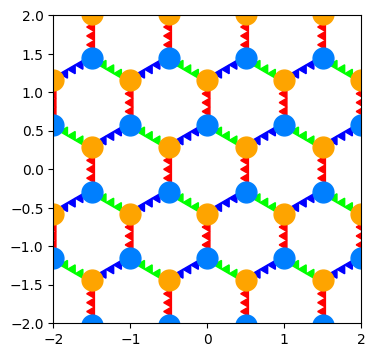

In [1]:
from gen_img4pub import (
    imgen
)

In [2]:
imgen.df

,fns,arr_clns,colors,nms,Ts,nano,sz,pxl20nm,k123
0,2HTaSe2_bad_78K097,"[[1.0103092144283519e-13, -3.5913526062327836e...",#9467bd,78K(1),78,160,2048,256,"[[114.0, 523.0], [-530.0, -177.0], [426.0, -34..."
1,2HTaSe2_ap_118K002,"[[-1.5468118784470648e-12, 1.358354867116372e-...",#1f77b4,118K,118,40,512,256,"[[18.0, 142.0], [-145.0, -48.0], [126.0, -94.0]]"
2,2HTaSe2_bae_110K012,"[[-1.399080145167011e-12, -2.5197514098938278e...",#ff7f0e,110K,110,80,1024,256,"[[47.0, 281.0], [-296.0, -95.0], [251.0, -185.0]]"
3,2HTaSe2_ao_115K037,"[[5.857832103672808e-13, 2.382601548993847e-12...",#289E28,115K,115,40,1024,512,"[[31.0, 142.0], [-149.0, -48.0], [118.0, -94.0]]"
4,test,"[[4.992021943206503e-12, 3.452972262860198e-12...",#d62728,78K(2),78,80,2048,512,"[[52.0, 258.0], [-277.0, -87.0], [225.0, -170.0]]"
5,110K_highres,"[[2.5767310122245523e-13, 4.0635659008804856e-...",#1f77b4,110K(2),110,40,1024,512,"[[26.0, 138.0], [-142.0, -47.0], [116.0, -91.0]]"
6,90K,"[[1.7600706963492184e-12, -1.0950594154867949e...",k,100K,90,40,1024,512,"[[-74.0, -129.0], [123.0, 35.0], [-52.0, 93.0]]"
7,100K,"[[-9.309954388728156e-12, -9.82275412185125e-1...",k,100K,100,40,1024,512,"[[-13.0, -137.0], [48.0, 37.0], [-34.0, 100.0]]"


In [3]:
from loader import load_H03
df = load_H03()
df

,fns,arr_clns,colors,nms,Ts,nano,sz,pxl20nm,k123,phase
0,2HTaSe2_bad_78K097,"[[1.0103092144283519e-13, -3.5913526062327836e...",#9467bd,78K(1),78,160,2048,256,"[[114.0, 523.0], [-530.0, -177.0], [426.0, -34...","[[[-2.0996356884472185, -2.068621200858523, -2..."
6,90K,"[[1.7600706963492184e-12, -1.0950594154867949e...",k,100K,90,40,1024,512,"[[-74.0, -129.0], [123.0, 35.0], [-52.0, 93.0]]","[[[5.491412475107197, 5.489123613842976, 5.484..."
7,100K,"[[-9.309954388728156e-12, -9.82275412185125e-1...",k,100K,100,40,1024,512,"[[-13.0, -137.0], [48.0, 37.0], [-34.0, 100.0]]","[[[3.233872823724029, 3.2340385521115964, 3.23..."
5,110K_highres,"[[2.5767310122245523e-13, 4.0635659008804856e-...",#1f77b4,110K(2),110,40,1024,512,"[[26.0, 138.0], [-142.0, -47.0], [116.0, -91.0]]","[[[5.389773847253473, 5.388461139619211, 5.385..."
3,2HTaSe2_ao_115K037,"[[5.857832103672808e-13, 2.382601548993847e-12...",#289E28,115K,115,40,1024,512,"[[31.0, 142.0], [-149.0, -48.0], [118.0, -94.0]]","[[[-5.095307753740863, -5.136761187831822, -5...."
1,2HTaSe2_ap_118K002,"[[-1.5468118784470648e-12, 1.358354867116372e-...",#1f77b4,118K,118,40,512,256,"[[18.0, 142.0], [-145.0, -48.0], [126.0, -94.0]]","[[[-9.837244096340234, -9.792643644973875, -9...."


In [17]:
import imagingPhase.get_phimap as gpm
import pandas as pd
ua = np.array([-1, 1])*np.pi
dfphase = pd.DataFrame({
'arrfcn':[lambda x:x,gpm.wrap_phase,lambda x: gpm.wrap_phase(3*x)/3],
'cmap':['jet','twilight_shifted','RdBu'],
'clim':[ua*3,ua*(1),ua*(1/3)],
'phaseStr':['monotonic','circular','circular(x3)'],
'ticks':[[-np.pi*3, -np.pi*(2/3), 0, np.pi*(2/3), np.pi*3],
    [-np.pi, -np.pi*(2/3), 0, np.pi*(2/3), np.pi],
    [ -np.pi*(1/3), 0, np.pi*(1/3)]],
'tick_labels':[[r"$-3\pi$", r"$-\frac{2}{3}\pi$" ,"", r"$\frac{2}{3}\pi$" ,r"$3\pi$"],
[r"$-\pi$", r"$-\frac{2}{3}\pi$" ,r"$0$", r"$\frac{2}{3}\pi$" ,r"$\pi$"],
[r"$-\frac{1}{3}\pi$" ,r"$0$", r"$\frac{1}{3}\pi$" ]]
})

In [4]:
import imagingPhase.ffts as imfft
def get_fft_prfl(arr_cln,k123):
    scl = 1.2
    atomPos = 1000      
    len_interp = int(atomPos*scl)+1#1201
    fft2abs = imfft.get_magnitude_spectrum(arr_cln)
    fft_pfls = []
    sz = arr_cln.shape
    p1 = np.array([sz[0]//2,sz[1]//2])
    for of3 in range(3):              
        p2 = k123[of3]*scl + p1
        fft_pfl = imfft.get_line_profile(fft2abs, p1, p2, len_interp)        
        fft_pfls.append(fft_pfl)
    return fft_pfls

def get_amp_shift(fft_pfl):
    amp_atom = fft_pfl[1000]
    start, end = 300, 360
    peak_index_relative = np.argmax(fft_pfl[start:end])
    peak_index_global = start + peak_index_relative
    amp_cdw = fft_pfl[peak_index_global]
    amp = amp_cdw/amp_atom
    shift = peak_index_global/1000
    return amp,shift

def circular_mean(phi):
    phi = phi.flatten()
    C = np.cos(tht).sum()
    S = np.sin(tht).sum()
    R  =np.sqrt(C**2+S**2)/len(tht)    
    THT = np.arctan2(S,C)
    return R,THT

In [12]:
T = df['Ts']
len(T)

6

In [ ]:
import numpy as np
fft_pflss = []
amp_shifts = []
for idx in range(len(T)):
    arr_cln = df['arr_clns'].iloc[idx]
    k123 = df['k123'].iloc[idx]
    fft_pfls = get_fft_prfl(arr_cln,k123)
    amp_shift = list(map(get_amp_shift,fft_pfls))
    fft_pflss.append(fft_pfls)
    amp_shifts.append(amp_shift)    

In [19]:
dfphaseNow = dfphase.iloc[2]
lockss = np.zeros((len(T),3))
vss = np.zeros((len(T),3,2))
for idx in range(len(T)):
    for ik in range(3):
        dt = df['phase'].iloc[idx][ik]
        x_grad,y_grad = np.gradient(dt)
        v = np.array([x_grad.mean(),y_grad.mean()])
        print(v)
        vss[idx][ik] = v
        dt_wrap =dfphaseNow['arrfcn'](dt)
        tht = dt_wrap*3
        tht = tht.flatten()
        R,THT = circular_mean(tht)
        lockss[idx][ik] = R
        print(idx,ik,R)

[0.00202021 0.00048361]
0 0 0.8336444579835446
[-0.00035967 -0.00287637]
0 1 0.8155502468543115
[-0.0025666   0.00245202]
0 2 0.8037893035997562
[0.00018072 0.00212459]
1 0 0.6723806798666705
[-0.00068781  0.0001514 ]
1 1 0.8040193115188624
[ 0.0001781  -0.00171012]
1 2 0.7327013417145728
[-0.00108157  0.00077844]
2 0 0.6191410330588955
[-0.00117366  0.0019571 ]
2 1 0.651920432057417
[ 0.00205517 -0.00243955]
2 2 0.6031780823524784
[0.00455479 0.00144226]
3 0 0.0991242465151691
[-0.00165362 -0.00456952]
3 1 0.09557719248207609
[-0.00358768  0.00419557]
3 2 0.1370994433639407
[0.00819072 0.00298869]
4 0 0.07214500125471689
[-0.00221111 -0.00567665]
4 1 0.13040378060951055
[-0.00628194  0.00300989]
4 2 0.0980358061357574
[0.01970408 0.01301726]
5 0 0.05889491535128009
[-0.00571781 -0.01985063]
5 1 0.1044892627786825
[-0.01246872  0.01489298]
5 2 0.06356697377352312


236.30472235710747
169.33884410435152
138.2890362744133
115.1063860957656
348.49533930111966
142.74823131598907
184.1821153452528


KeyError: 2

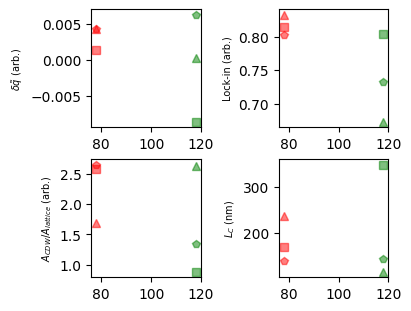

In [ ]:
import matplotlib.pyplot as plt
c = ["r","g","g","g","b","y"]
mk = ['^','s','p']
fig,axs = plt.subplots(2,2,figsize=(4,3),constrained_layout=True)
iinfo = 0
nm_info = [r'$\delta \tilde{q}$ (arb.)' ,'Lock-in (arb.)','$A_{CDW}/A_{lattice}$ (arb.)','$L_C$ (nm)']
for isb in range(2):
    for jsb in range(2):
        plt.sca(axs[isb,jsb])                
        plt.ylabel(nm_info[iinfo], fontsize=7)
        iinfo += 1
for idx in range(len(T)):
    for ik in range(3):
        v = vss[idx,ik,:]
        lock = lockss[idx][ik]
        v_amp = np.sqrt(v[0]**2 + v[1]**2)
        amp_shift = amp_shifts[idx][ik]
        l_measure =df['nano'].iloc[idx]
        N_tot = df['sz'].iloc[idx]
        l_return = (2*np.pi*l_measure)/(v_amp*N_tot)
        print(l_return)
        # print(T[idx],1/v_amp)
        axs[0,0].plot(T[idx],1/3-amp_shift[1],color=c[idx],marker=mk[ik],alpha=0.5)
        axs[1,0].plot(T[idx],amp_shift[0],color=c[idx],marker=mk[ik],alpha=0.5)
        axs[0,1].plot(T[idx],lock,color=c[idx],marker=mk[ik],alpha=0.5)
        axs[1,1].plot(T[idx],l_return,color=c[idx],marker=mk[ik],alpha=0.5)

        
axs[0,0].axhline(y=0,color='k',linewidth=0.5)
axs[0,1].axhline(y=0,color='k',linewidth=0.5)        
axs[0,1].axhline(y=1,color='k',linewidth=0.5)        
axs[1,0].axhline(y=0,color='k',linewidth=0.5)        
# axs[1,0].axhline(y=1,color='k',linewidth=0.5)        
axs[1,1].axhline(y=0,color='k',linewidth=0.5)      
axs[1,0].set_xlabel(r'$T $ [K]')
axs[1,1].set_xlabel(r'$T $ [K]')
# plt.savefig('C05_Fig3_statitics.svg')
